In [3]:
!pip install transformers

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import gzip
import json
import pandas as pd

file_path = '/content/drive/MyDrive/Amazon-Product-review-Analysis/Movies_and_TV.jsonl.gz'

In [9]:
import os

print("File exists?", os.path.exists(file_path))

File exists? True


In [11]:
!ls -l "/content/drive/MyDrive/Amazon-Product-review-Analysis/"

total 2627568
-rw------- 1 root root      21938 Feb 12 00:16 'Amazon Product Analysis.ipynb'
-rw------- 1 root root  274203627 Dec  3 22:33  meta_Movies_and_TV.jsonl.gz
-rw------- 1 root root 2416403168 Dec  3 23:00  Movies_and_TV.jsonl.gz


In [12]:
import gzip, json

with gzip.open(file_path, 'rt', encoding='utf-8') as f:
    for i, line in enumerate(f):
        data = json.loads(line.strip())
        print(data)
        if i > 5:
            break

{'rating': 5.0, 'title': 'Five Stars', 'text': "Amazon, please buy the show! I'm hooked!", 'images': [], 'asin': 'B013488XFS', 'parent_asin': 'B013488XFS', 'user_id': 'AGGZ357AO26RQZVRLGU4D4N52DZQ', 'timestamp': 1440385637000, 'helpful_vote': 0, 'verified_purchase': True}
{'rating': 5.0, 'title': 'Five Stars', 'text': 'My Kiddos LOVE this show!!', 'images': [], 'asin': 'B00CB6VTDS', 'parent_asin': 'B00CB6VTDS', 'user_id': 'AGKASBHYZPGTEPO6LWZPVJWB2BVA', 'timestamp': 1461100610000, 'helpful_vote': 0, 'verified_purchase': True}
{'rating': 3.0, 'title': 'Some decent moments...but...', 'text': "Annabella Sciorra did her character justice with her portrayal of a mentally ill, depressed and traumatized individual who projects much of her inner wounds onto others. The challenges she faces with her father were sensitively portrayed and resonate with understanding and love. The ending really isn't an ending, though and feels like it was abandoned with not enough of a closure but other than that

In [15]:
reviews = []
max_lines = 50000  # Increase or remove this limit to read the full dataset

with gzip.open(file_path, 'rt', encoding='utf-8') as f:
    for i, line in enumerate(f):
        data = json.loads(line.strip())

        # Check if 'text' and 'rating' keys exist in the JSON
        if 'text' in data and 'rating' in data:
            text = data['text']
            rating = data['rating']
            reviews.append((text, rating))

        if i >= max_lines - 1:  # Stop after reading max_lines
            break

# Create a DataFrame, naming the columns as desired
df = pd.DataFrame(reviews, columns=['reviewText', 'rating'])
print("Number of samples read:", len(df))
df.head()

Number of samples read: 50000


,reviewText,rating
0,"Amazon, please buy the show! I'm hooked!",5.0
1,My Kiddos LOVE this show!!,5.0
2,Annabella Sciorra did her character justice wi...,3.0
3,...there should be more of a range of characte...,4.0
4,"...isn't always how you expect it to be, but w...",5.0


from matplotlib import pyplot as plt
_df_0['rating'].plot(kind='hist', bins=20, title='rating')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
_df_1.groupby('reviewText').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2['rating'].plot(kind='line', figsize=(8, 4), title='rating')
plt.gca().spines[['top', 'right']].set_visible(False)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_3['reviewText'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_3, x='rating', y='reviewText', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

In [13]:
print(df.shape)

(0, 2)


### **Three class model**

- For a 3-class model:

 - Class 0: Rating ≤ 2 (Negative)
 - Class 1: Rating = 3 (Neutral)
 - Class 2: Rating ≥ 4 (Positive)

In [16]:
def label_sentiment_3class(r):
    if r <= 2:
        return 0  # Negative
    elif r == 3:
        return 1  # Neutral
    else:
        return 2  # Positive

df['sentiment_3class'] = df['rating'].apply(label_sentiment_3class)
print(df['sentiment_3class'].value_counts())

sentiment_3class
2    40428
0     5245
1     4327
Name: count, dtype: int64


### **Test-Train Split**

In [17]:
from sklearn.model_selection import train_test_split

X = df['reviewText'].values
y = df['sentiment_3class'].values  # 3-class labels now

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", len(X_train))
print("Test size: ", len(X_test))

Train size: 40000
Test size:  10000


### **Import libraries & define PyTorch dataset:**

In [18]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification, AdamW
from sklearn.metrics import classification_report, accuracy_score

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

class ReviewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

train_dataset = ReviewsDataset(X_train, y_train, tokenizer)
test_dataset  = ReviewsDataset(X_test, y_test, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

### **Initialize the model with num_labels=3:**

In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=3  # 3 classes: negative, neutral, positive
)
model = model.to(device)

optimizer = AdamW(model.parameters(), lr=2e-5)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.11/dist-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


### **Train and Evaluate**

In [20]:
epochs = 2  # Adjust as needed

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch in train_loader:
        optimizer.zero_grad()

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{epochs}] | Avg Training Loss: {avg_loss:.4f}")

    # Validation
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    print(f"Validation Accuracy: {acc:.4f}\n")

print("Classification Report (3-class):")
print(classification_report(all_labels, all_preds, target_names=['Negative','Neutral','Positive']))

Epoch [1/2] | Avg Training Loss: 0.3338
Validation Accuracy: 0.8848

Epoch [2/2] | Avg Training Loss: 0.2362
Validation Accuracy: 0.8895

Classification Report (3-class):
              precision    recall  f1-score   support

    Negative       0.70      0.79      0.74      1049
     Neutral       0.53      0.33      0.41       865
    Positive       0.94      0.96      0.95      8086

    accuracy                           0.89     10000
   macro avg       0.72      0.69      0.70     10000
weighted avg       0.88      0.89      0.88     10000



---

## **Star Rating Regression (Predict 1–5 Directly)**

**Label Setup**

In [21]:
y = df['rating'].values

**BERT for Regression**

In [22]:
model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=1,
    problem_type="regression"
)
model = model.to(device)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


**Adjust the Loss & Predictions**

By default, `BertForSequenceClassification` uses **CrossEntropy** for classification. With `num_labels=1` and `problem_type="regression"`, it should switch to **MSELoss** under the hood. Your `labels` must be floats:

In [23]:
import torch
from torch.utils.data import Dataset, DataLoader

class ReviewsRegressionDataset(Dataset):
    def __init__(self, texts, ratings, tokenizer, max_len=128):
        self.texts = texts
        self.ratings = ratings
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        rating = float(self.ratings[idx])
        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(rating, dtype=torch.float)
        }

# Reuse the same data splits but for a regression dataset
train_dataset = ReviewsRegressionDataset(X_train, y_train, tokenizer)
test_dataset  = ReviewsRegressionDataset(X_test, y_test, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False)

optimizer = AdamW(model.parameters(), lr=2e-5)

epochs = 2
for epoch in range(epochs):
    model.train()
    total_loss = 0.0
    for batch in train_loader:
        optimizer.zero_grad()

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)  # float labels

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss  # MSELoss by default for regression
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}, Avg Train Loss: {total_loss/len(train_loader):.4f}")

# Evaluate
model.eval()
preds_list = []
labels_list = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].cpu().numpy()  # ground truth

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        # outputs.logits shape = (batch_size, 1)
        preds = outputs.logits.squeeze(-1).cpu().numpy()  # predicted ratings
        preds_list.extend(preds)
        labels_list.extend(labels)

# Convert to numpy arrays
import numpy as np

preds_list = np.array(preds_list)
labels_list = np.array(labels_list)

# Evaluate with RMSE or MAE
from sklearn.metrics import mean_squared_error, mean_absolute_error
rmse = np.sqrt(mean_squared_error(labels_list, preds_list))
mae = mean_absolute_error(labels_list, preds_list)

print(f"Regression RMSE: {rmse:.4f}")
print(f"Regression MAE: {mae:.4f}")

/usr/local/lib/python3.11/dist-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Epoch 1/2, Avg Train Loss: 0.1894
Epoch 2/2, Avg Train Loss: 0.1135
Regression RMSE: 0.4036
Regression MAE: 0.2273


---

## **LSTM-Based 3-Class Sentiment Classification**

This section covers how to train an LSTM on your existing 3-class labels:

- 0 = Negative (rating ≤ 2)
- 1 = Neutral (rating = 3)
- 2 = Positive (rating ≥ 4)

We’ll reuse your df with columns:

- reviewText (the text)
- sentiment_3class (the label: 0, 1, or 2)


**Data Preprocessing & Splitting**

In [24]:
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

X = df['reviewText'].values
y = df['sentiment_3class'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 40000
Test size: 10000


**Tokenization for LSTM**

In [25]:
import re
import string
from collections import Counter

def clean_text(text):
    # Basic text cleaning (remove punctuation, lowercasing, etc.)
    text = text.lower()
    text = re.sub(f"[{re.escape(string.punctuation)}]", "", text)
    return text

# Clean train/test text
X_train_clean = [clean_text(t) for t in X_train]
X_test_clean  = [clean_text(t) for t in X_test]

# Build vocabulary from training data
words = " ".join(X_train_clean).split()
vocab_count = Counter(words)
# Optional: remove very rare words or set a vocab_size limit
vocab = sorted(vocab_count, key=vocab_count.get, reverse=True)
word_to_idx = {word: i+2 for i, word in enumerate(vocab)}
# +2 to reserve 0 for PAD, 1 for OOV

def text_to_sequence(text, max_len=100):
    tokens = text.split()
    seq = []
    for token in tokens[:max_len]:
        if token in word_to_idx:
            seq.append(word_to_idx[token])
        else:
            seq.append(1)  # 1 = OOV
    # Pad if shorter than max_len
    if len(seq) < max_len:
        seq += [0] * (max_len - len(seq))
    return seq[:max_len]  # ensure exact length

max_seq_len = 100

X_train_seq = [text_to_sequence(t, max_seq_len) for t in X_train_clean]
X_test_seq  = [text_to_sequence(t, max_seq_len) for t in X_test_clean]

# Convert to numpy
X_train_seq = np.array(X_train_seq)
X_test_seq  = np.array(X_test_seq)
y_train = np.array(y_train)
y_test  = np.array(y_test)

**PyTorch Dataset & DataLoader**

In [26]:
class LSTMDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = sequences
        self.labels = labels

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        seq = self.sequences[idx]
        label = self.labels[idx]
        return {
            'input_seq': torch.tensor(seq, dtype=torch.long),
            'label': torch.tensor(label, dtype=torch.long)
        }

train_dataset = LSTMDataset(X_train_seq, y_train)
test_dataset  = LSTMDataset(X_test_seq, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

**Define the LSTM Model**

In [27]:
import torch.nn as nn

class SentimentLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim, padding_idx=0):
        super(SentimentLSTM, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=padding_idx)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # x shape: (batch_size, seq_len)
        embedded = self.embedding(x)      # (batch_size, seq_len, embed_dim)
        lstm_out, (h, c) = self.lstm(embedded)  # h shape: (1, batch_size, hidden_dim)
        # Take the last hidden state
        out = self.fc(h[-1])  # (batch_size, output_dim)
        return out

# Hyperparams
vocab_size = len(word_to_idx) + 2  # +2 for PAD/OOV placeholders
embed_dim = 128
hidden_dim = 128
output_dim = 3  # 3 classes: Negative, Neutral, Positive

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_lstm = SentimentLSTM(vocab_size, embed_dim, hidden_dim, output_dim)
model_lstm.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_lstm.parameters(), lr=1e-3)

**Train the LSTM**

In [29]:
epochs = 3
for epoch in range(epochs):
    model_lstm.train()
    total_loss = 0
    for batch in train_loader:
        seqs = batch['input_seq'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model_lstm(seqs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    # Evaluate
    model_lstm.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for batch in test_loader:
            seqs = batch['input_seq'].to(device)
            labels = batch['label'].to(device)
            logits = model_lstm(seqs)
            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    print(f"Epoch {epoch+1}/{epochs}, Train Loss: {avg_loss:.4f}, Val Acc: {acc:.4f}")

Epoch 1/3, Train Loss: 0.6108, Val Acc: 0.8087
Epoch 2/3, Train Loss: 0.5939, Val Acc: 0.8076
Epoch 3/3, Train Loss: 0.5688, Val Acc: 0.7931


**Classification Report**

In [30]:
print("LSTM 3-Class Classification Report:")
print(classification_report(all_labels, all_preds, target_names=['Negative','Neutral','Positive']))

LSTM 3-Class Classification Report:
              precision    recall  f1-score   support

    Negative       0.25      0.04      0.07      1049
     Neutral       0.14      0.03      0.05       865
    Positive       0.81      0.97      0.89      8086

    accuracy                           0.79     10000
   macro avg       0.40      0.35      0.34     10000
weighted avg       0.70      0.79      0.73     10000



---

### **Ad Ranking Logic (Aggregation)**

In [31]:
df['pred_sentiment'] = None  # placeholder

batch_size = 32

def predict_bert_sentiment(text_list, tokenizer, model, device='cpu', max_len=128):
    model.eval()
    preds_total = []

    dataset_list = []
    for txt in text_list:
        encoding = tokenizer.encode_plus(
            txt,
            add_special_tokens=True,
            max_length=max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )
        dataset_list.append((
            encoding['input_ids'].squeeze(0),
            encoding['attention_mask'].squeeze(0)
        ))

    # batch data
    for start_idx in range(0, len(dataset_list), batch_size):
        batch_data = dataset_list[start_idx:start_idx+batch_size]
        input_ids_batch = torch.stack([bd[0] for bd in batch_data]).to(device)
        attention_mask_batch = torch.stack([bd[1] for bd in batch_data]).to(device)

        with torch.no_grad():
            outputs = model(input_ids=input_ids_batch, attention_mask=attention_mask_batch)
            logits = outputs.logits
            preds = torch.argmax(logits, dim=1)
        preds_total.extend(preds.cpu().numpy())

    return preds_total

# Now let's run inference on the entire df
text_list = df['reviewText'].tolist()
predictions = predict_bert_sentiment(text_list, tokenizer, model, device=device)
df['pred_sentiment'] = predictions

---



In [33]:
!pip install matplotlib seaborn wordcloud

**Rating Distribution Histogram**

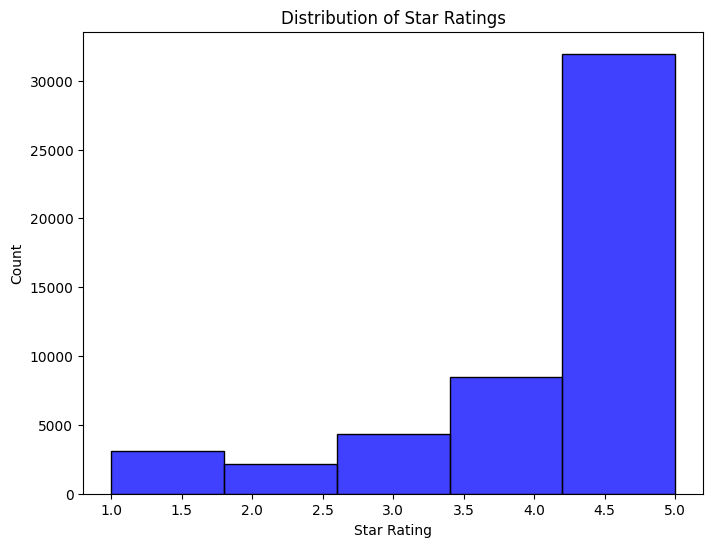

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.histplot(data=df, x='rating', bins=5, kde=False, color='blue')
plt.title("Distribution of Star Ratings")
plt.xlabel("Star Rating")
plt.ylabel("Count")
plt.show()

**3-class sentiment countplot**

<ipython-input-35-8638f716351b>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment_3class', data=df, palette='viridis')


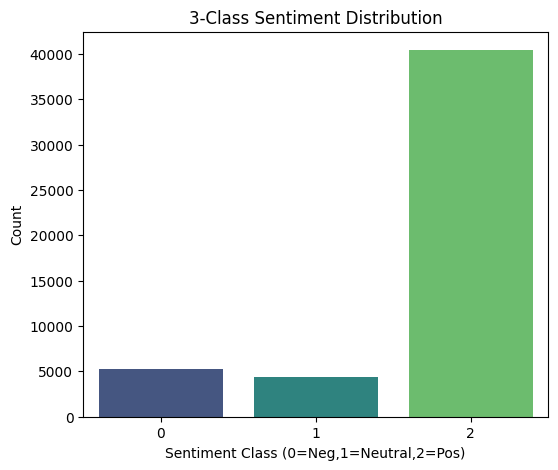

In [35]:
# Assumes df['sentiment_3class'] is in {0=Neg, 1=Neutral, 2=Pos}
plt.figure(figsize=(6,5))
sns.countplot(x='sentiment_3class', data=df, palette='viridis')
plt.title("3-Class Sentiment Distribution")
plt.xlabel("Sentiment Class (0=Neg,1=Neutral,2=Pos)")
plt.ylabel("Count")
plt.show()

**Length of Review**

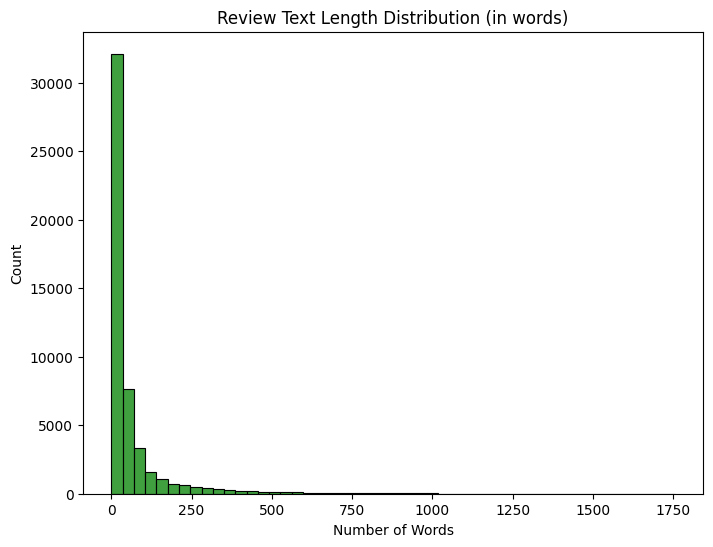

In [36]:
df['review_length'] = df['reviewText'].apply(lambda x: len(str(x).split()))
plt.figure(figsize=(8,6))
sns.histplot(df['review_length'], bins=50, color='green')
plt.title("Review Text Length Distribution (in words)")
plt.xlabel("Number of Words")
plt.ylabel("Count")
plt.show()

**Sentiment vs review length boxplot**

<ipython-input-37-e26fd81f1404>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='sentiment_3class', y='review_length', data=df, palette='Set2')


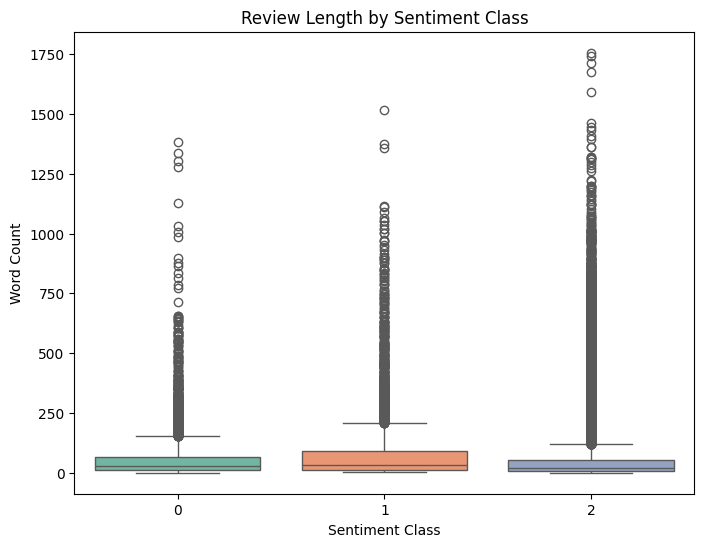

In [37]:
plt.figure(figsize=(8,6))
sns.boxplot(x='sentiment_3class', y='review_length', data=df, palette='Set2')
plt.title("Review Length by Sentiment Class")
plt.xlabel("Sentiment Class")
plt.ylabel("Word Count")
plt.show()

In [38]:
# Example: Save a 3-class BERT model
model.save_pretrained("bert_3class_model")
tokenizer.save_pretrained("bert_3class_tokenizer")

('bert_3class_tokenizer/tokenizer_config.json',
 'bert_3class_tokenizer/special_tokens_map.json',
 'bert_3class_tokenizer/vocab.txt',
 'bert_3class_tokenizer/added_tokens.json')

In [2]:
torch.save(model_lstm.state_dict(), "/content/drive/MyDrive/Amazon-Product-review-Analysis/lstm_sentiment.pth")
model.save_pretrained("/content/drive/MyDrive/Amazon-Product-review-Analysis/bert_3class_model")

NameError: name 'model_lstm' is not defined